# Round 1 — Contrast-aware multi-view representation research

**Question:** Which complementary MRI views and contrast combinations can the inference pipeline actually represent?

This is a feature-construction and quality-assurance round, not a trained-model comparison. Preserve expert-label evaluation. No AUC gain is claimed.

**Prerequisites:** current passing tests, copied-link metadata acquisition, and a completed notebook 01. Use the **RSNA Knee - audit** kernel. Restart Kernel and Run All; save, close, and reopen to inspect all 12 inline charts.

**Budget:** CPU only, zero model fits; two bounded worker invocations (first pauses intentionally, second resumes). Read `docs/FEATURE_RESEARCH.md` for domain hypotheses, limitations, and future matched ablations.

In [1]:
from pathlib import Path
import json
import sys
import plotly.io as pio
ROOT = next((p for p in (Path.cwd(), Path.cwd().parent) if (p / 'configs/research_rounds.json').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the rsna-knee-abnormality-detection project.')
sys.path.insert(0, str(ROOT / 'src'))
from rsna_knee.runtime import run_bounded, require_tests
from rsna_research.workflow import checked_m01, checked_round1
from rsna_research.visuals import round1_figure, round2_figure
pio.renderers.default = 'plotly_mimetype'
receipt = require_tests(ROOT)
checked_m01(ROOT)
print('Current-source tests and metadata integrity gates passed.')
print('No training, account action, or data download is performed by this notebook.')

Current-source tests and metadata integrity gates passed.
No training, account action, or data download is performed by this notebook.


## Controlled pause and resumption
The first worker checkpoints construction. The second must reuse it and complete diagnostics. Do not manually interrupt.

In [2]:
run_bounded([sys.executable, 'scripts/run_feature_round.py', '--round', '1', '--pause-after', 'construction'],
            ROOT, seconds=210, rss_gib=4, log_path=ROOT/'logs/r01_pause.log')
pause = json.loads((ROOT/'artifacts/r01_pause.json').read_text())
assert pause['status'] == 'paused'
run_bounded([sys.executable, 'scripts/run_feature_round.py', '--round', '1'],
            ROOT, seconds=210, rss_gib=4, log_path=ROOT/'logs/r01_resume.log')
latest = json.loads((ROOT/'artifacts/r01_latest.json').read_text())
assert latest['status'] == 'complete' and latest['key'] == pause['key']
assert latest['stages']['construction'] == 'reused_verified'
assert latest['raw_inputs_unchanged'] and latest['model_fits'] == 0 and latest['official_score'] is None
DIRECTORY = checked_round1(ROOT)
summary = json.loads((DIRECTORY/'construction_summary.json').read_text())
assert summary['new_columns'] == 65 and summary['total_columns'] == 130
print('Construction checkpoint reused; 130 total candidates, including 65 new columns. No model fit.')

{"utc": "2026-09-13T23:17:40.807230+00:00", "stage": "construction", "event": "computed", "completed": 0, "total": 1, "total_elapsed_s": 0.002, "stage_elapsed_s": 0.0, "rss_gib": 0.071}
{"utc": "2026-09-13T23:17:42.016528+00:00", "stage": "construction", "event": "complete", "completed": 1, "total": 1, "total_elapsed_s": 1.212, "stage_elapsed_s": 1.209, "rss_gib": 0.111}
{
  "key": "fce2c47262e4325efb3bd874e1b7fd9a5b64e4573d0361f465f759b2dfdc2d28",
  "status": "paused",
  "stages": {
    "construction": "computed"
  },
  "run_directory": "artifacts/r01/fce2c47262e4325efb3b"
}
{"utc": "2026-09-13T23:17:42.544975+00:00", "stage": "construction", "event": "reused_verified", "completed": 0, "total": 1, "total_elapsed_s": 0.012, "stage_elapsed_s": 0.0, "rss_gib": 0.071}
{"utc": "2026-09-13T23:17:42.545175+00:00", "stage": "construction", "event": "complete", "completed": 1, "total": 1, "total_elapsed_s": 0.012, "stage_elapsed_s": 0.0, "rss_gib": 0.071}
{"utc": "2026-09-13T23:17:42.545421+00

## 01. Representation inventory

Compare the preserved 65-column panel with the 65 newly constructed candidates. A larger panel is not a performance improvement.

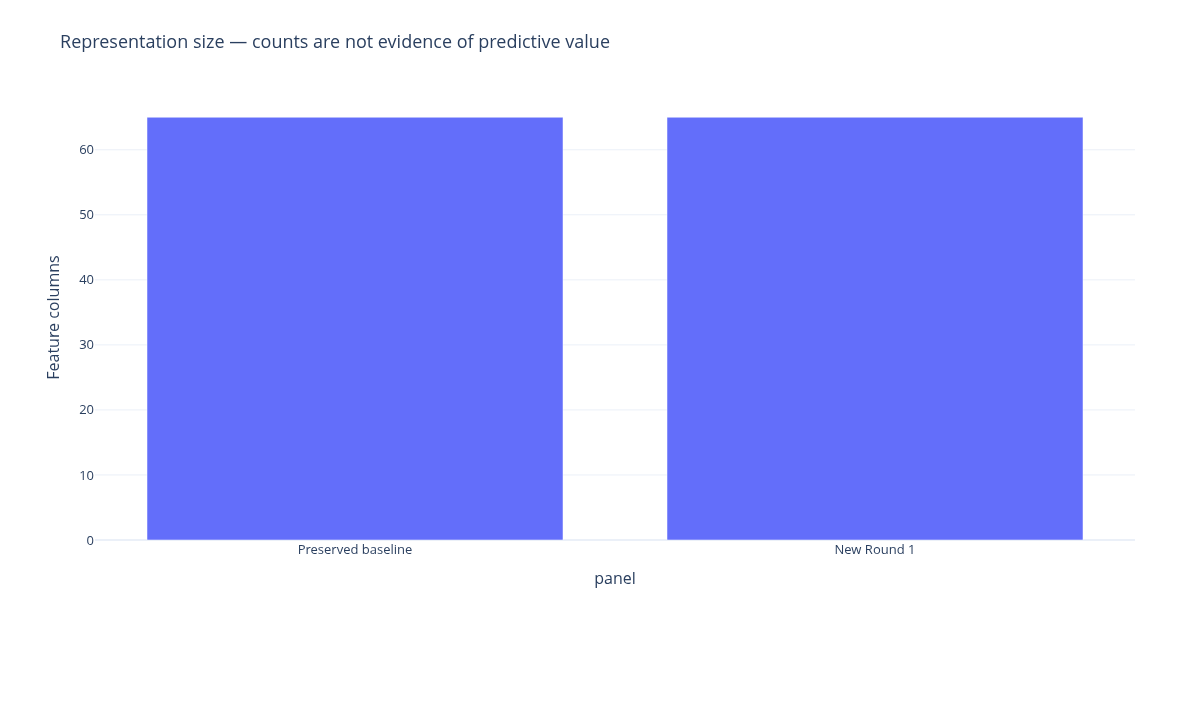

In [3]:
figure = round1_figure(DIRECTORY, 1)
figure.show(renderer='plotly_mimetype')

## 02. Domain-family coverage

Eight new families have explicit formulas and tests. Column count measures implementation scope, not predictive strength.

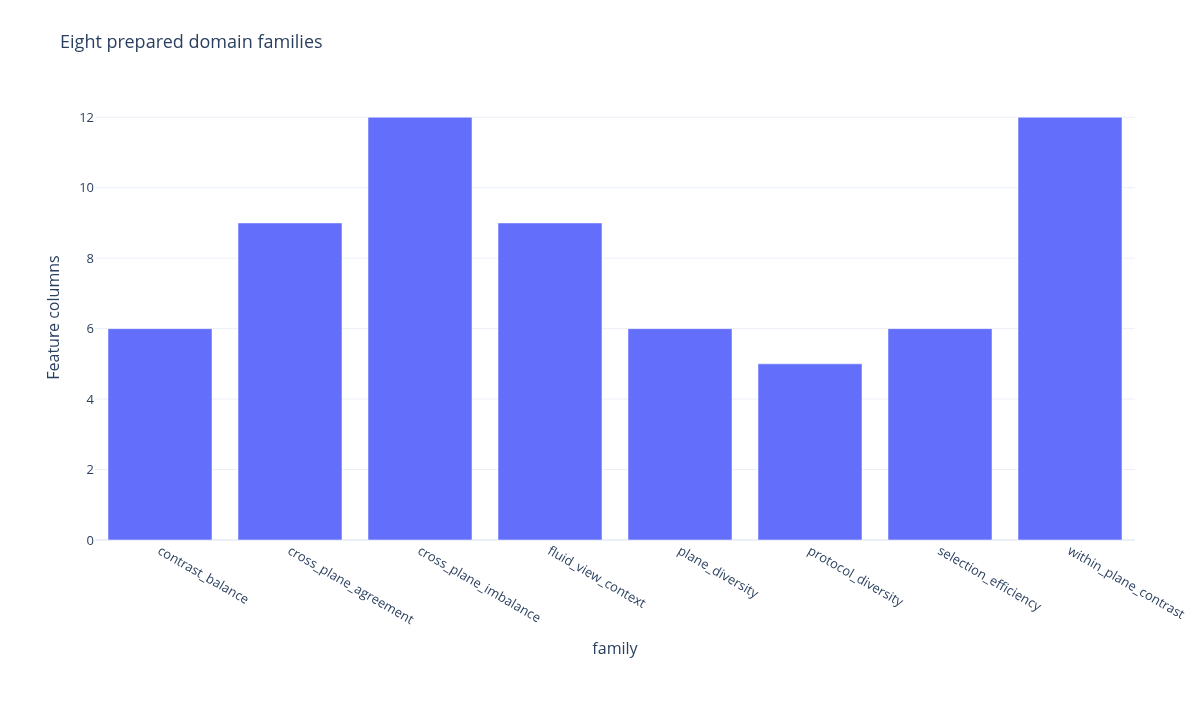

In [4]:
figure = round1_figure(DIRECTORY, 2)
figure.show(renderer='plotly_mimetype')

## 03. Observed variation

Constant or low-variation candidates may be uninformative in this development pool. Do not generalize from variation to disease association.

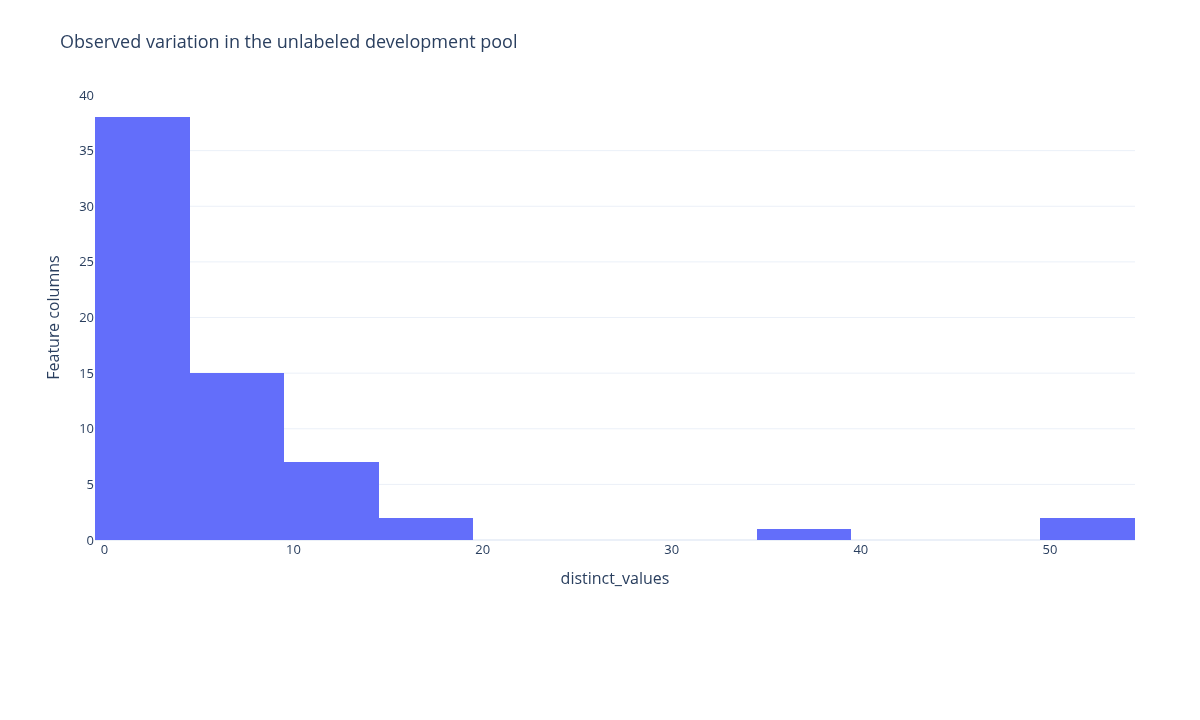

In [5]:
figure = round1_figure(DIRECTORY, 3)
figure.show(renderer='plotly_mimetype')

## 04. Absent representations

Zeros can encode absent contrasts or lack of diversity. They must not be confused with negative clinical findings.

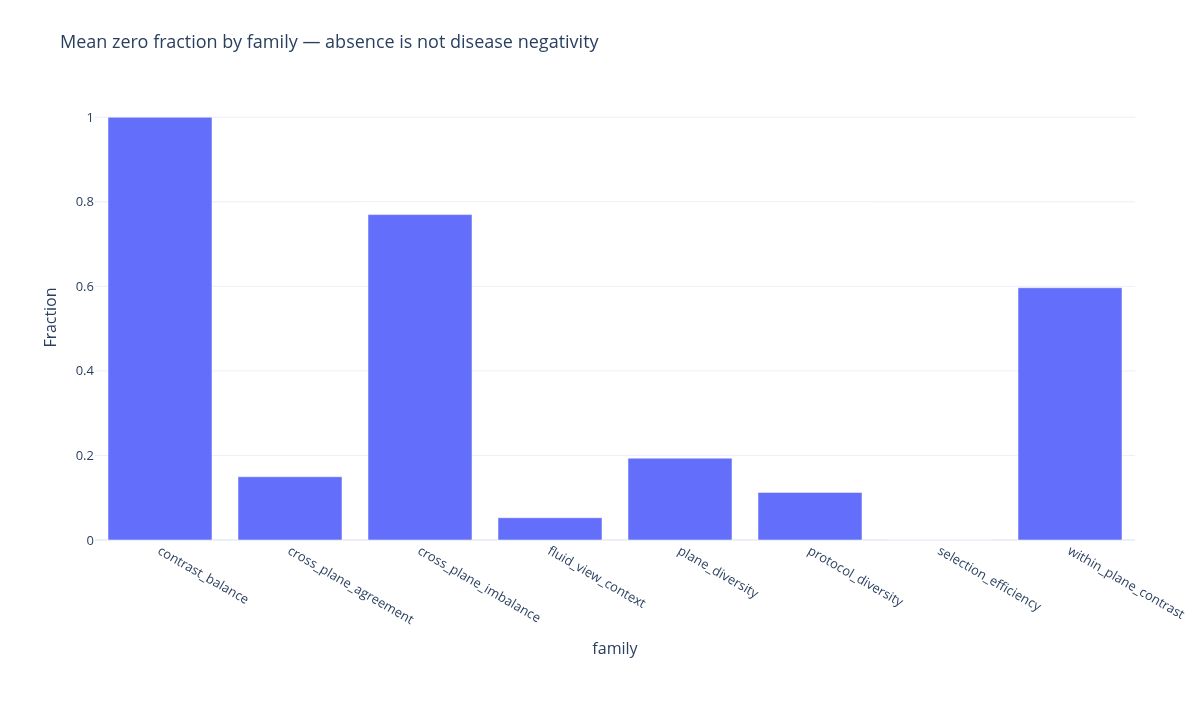

In [6]:
figure = round1_figure(DIRECTORY, 4)
figure.show(renderer='plotly_mimetype')

## 05. Constant-feature audit

This is descriptive quality assurance. No supervised feature selection is fitted here; later selection belongs inside training folds.

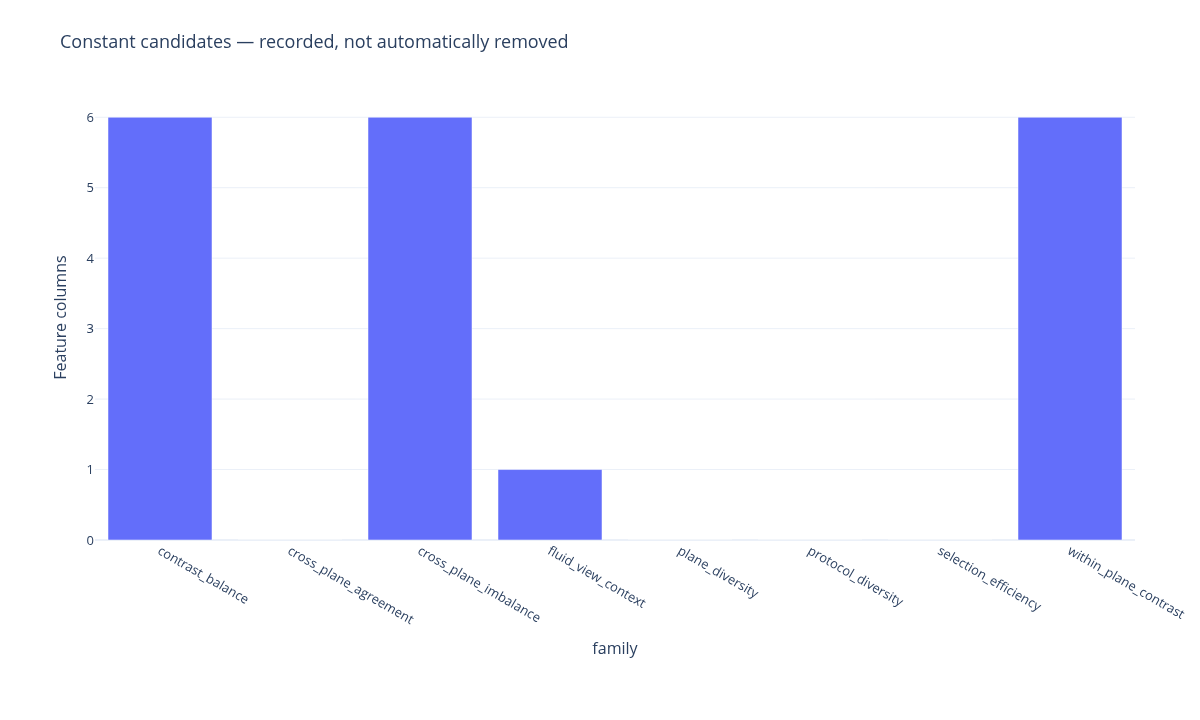

In [7]:
figure = round1_figure(DIRECTORY, 5)
figure.show(renderer='plotly_mimetype')

## 06. Scale audit

Families have different descriptor units. The ranges identify preprocessing considerations, not a ranking of feature importance.

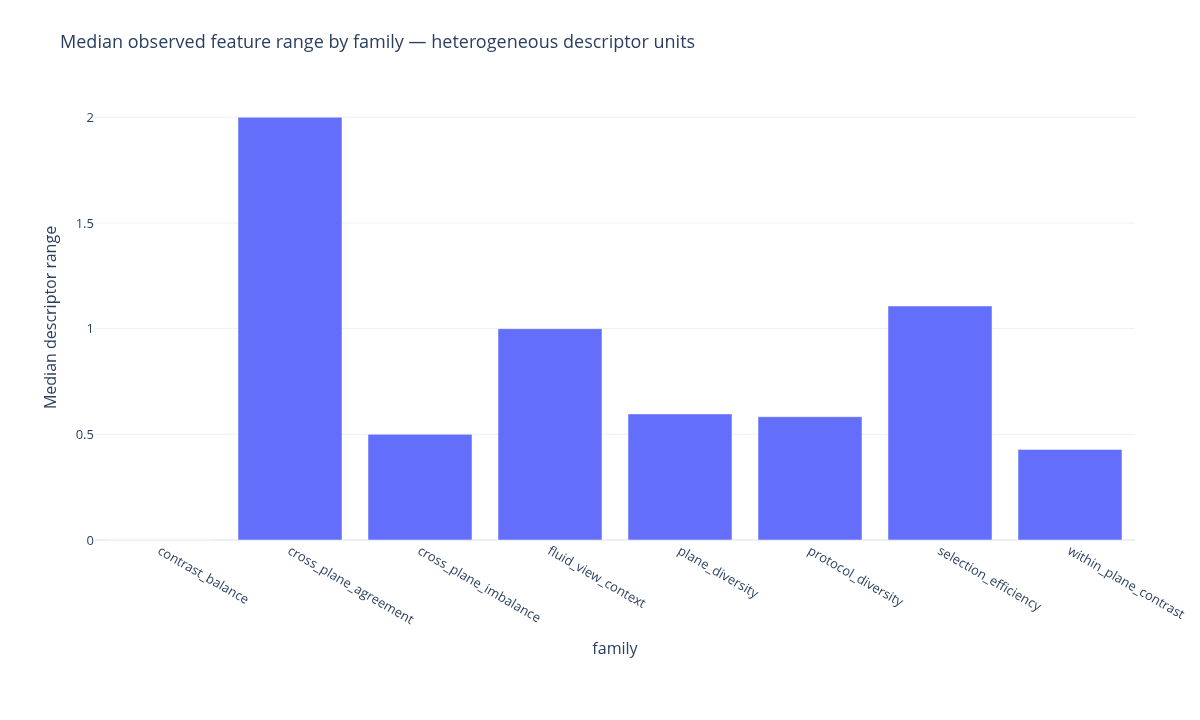

In [8]:
figure = round1_figure(DIRECTORY, 6)
figure.show(renderer='plotly_mimetype')

## 07. Bounded image plan

The plan reserves at most two unlabeled studies and one preferred series per available plane. Selection uses fixed rules, not disease labels.

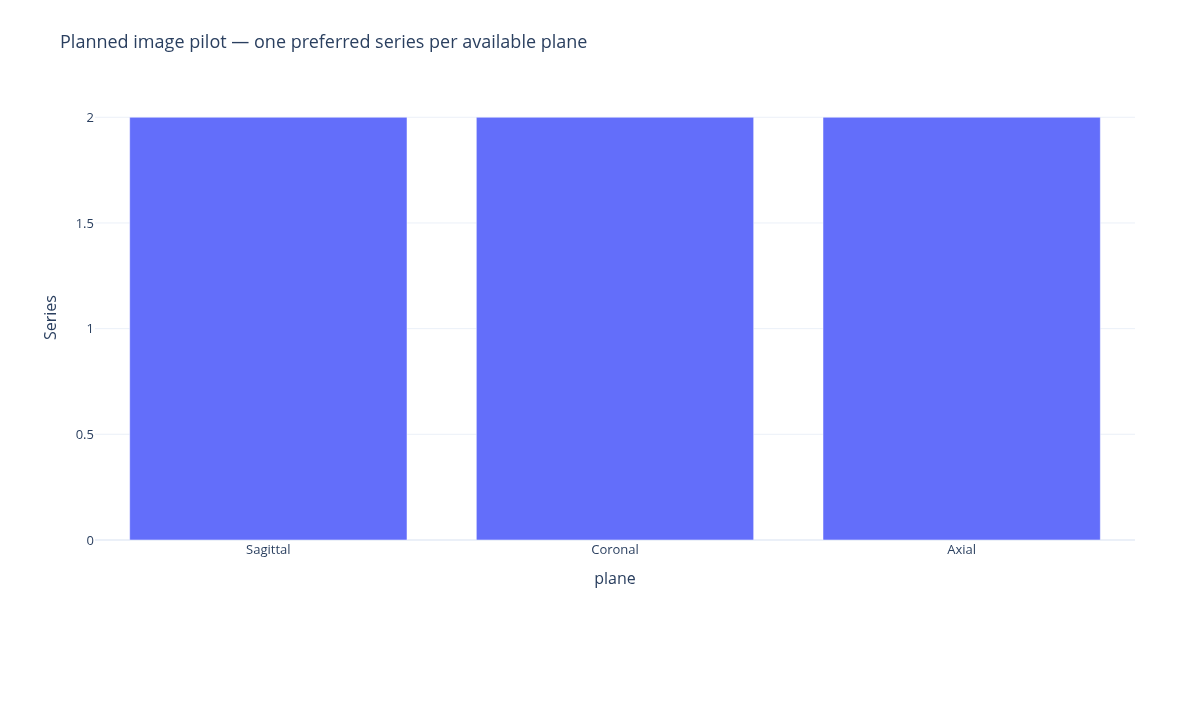

In [9]:
figure = round1_figure(DIRECTORY, 7)
figure.show(renderer='plotly_mimetype')

## 08. Conditional contrast coverage

Within-plane proportions separate contrast availability from overall series count. Missing-plane status remains explicit.

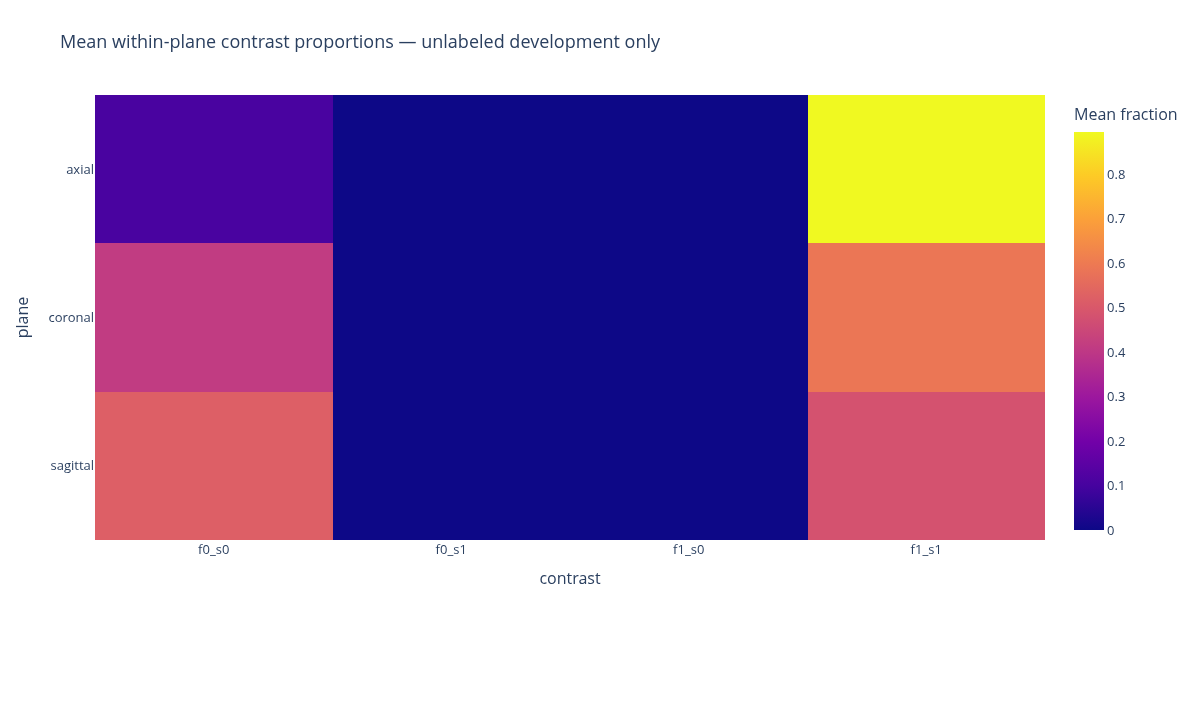

In [10]:
figure = round1_figure(DIRECTORY, 8)
figure.show(renderer='plotly_mimetype')

## 09. Protocol entropy

The error bars are observed minimum-to-maximum ranges, not confidence intervals. Entropy describes protocol diversity.

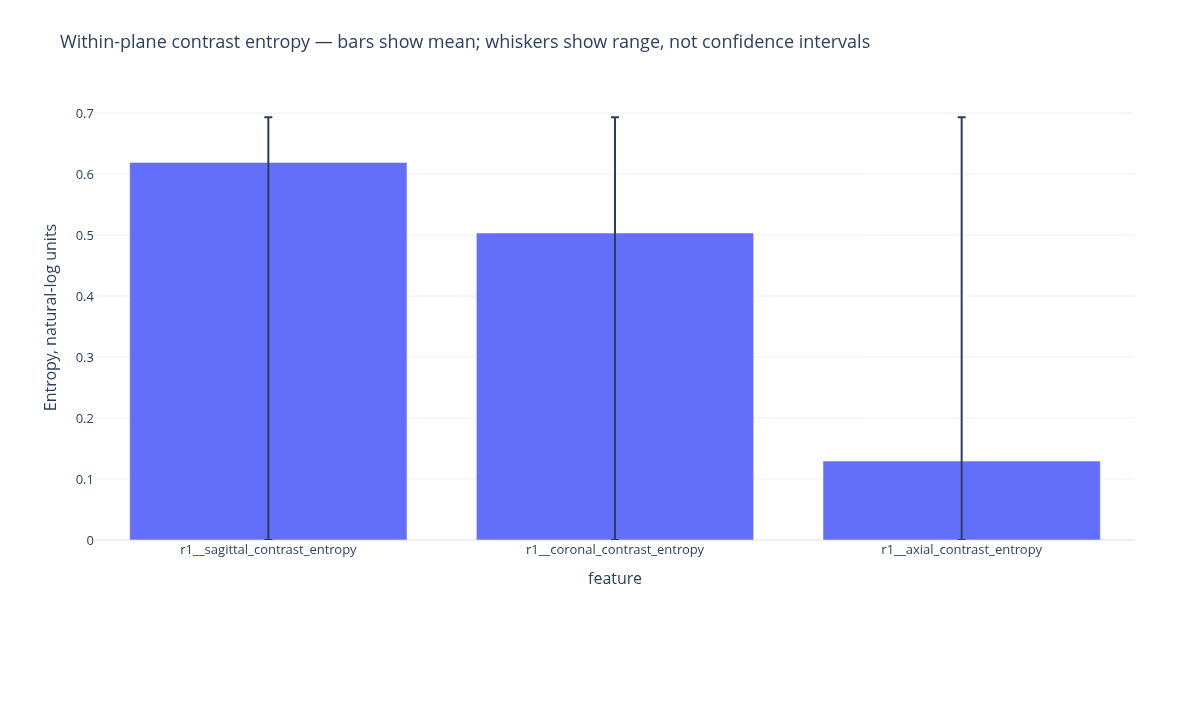

In [11]:
figure = round1_figure(DIRECTORY, 9)
figure.show(renderer='plotly_mimetype')

## 10. Complementary views

Contrast-set overlap is a coverage descriptor, not measured anatomical agreement or a direct disease marker.

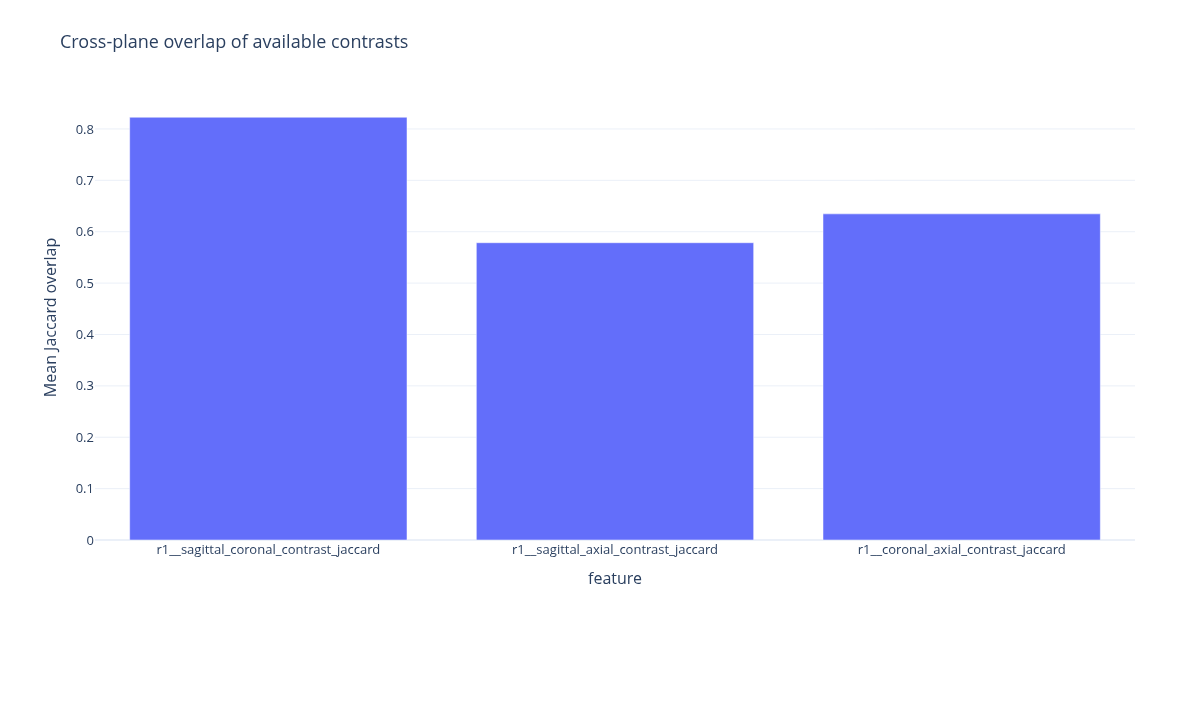

In [12]:
figure = round1_figure(DIRECTORY, 10)
figure.show(renderer='plotly_mimetype')

## 11. Evaluation protection

Expert-labeled studies and exact normalized-report duplicates are reserved. This does not prove patient- or site-disjointness.

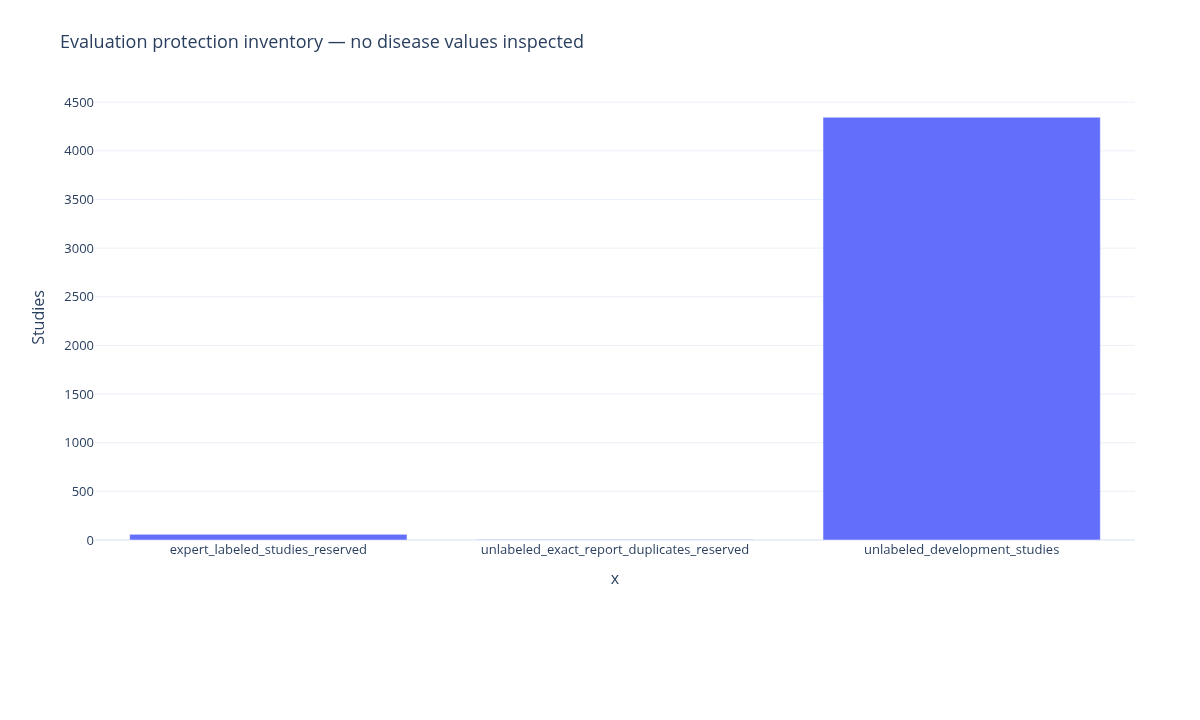

In [13]:
figure = round1_figure(DIRECTORY, 11)
figure.show(renderer='plotly_mimetype')

## 12. Redundancy audit

Several series can repeat the same plane/contrast. Later controlled image experiments must establish whether selection helps the official metric.

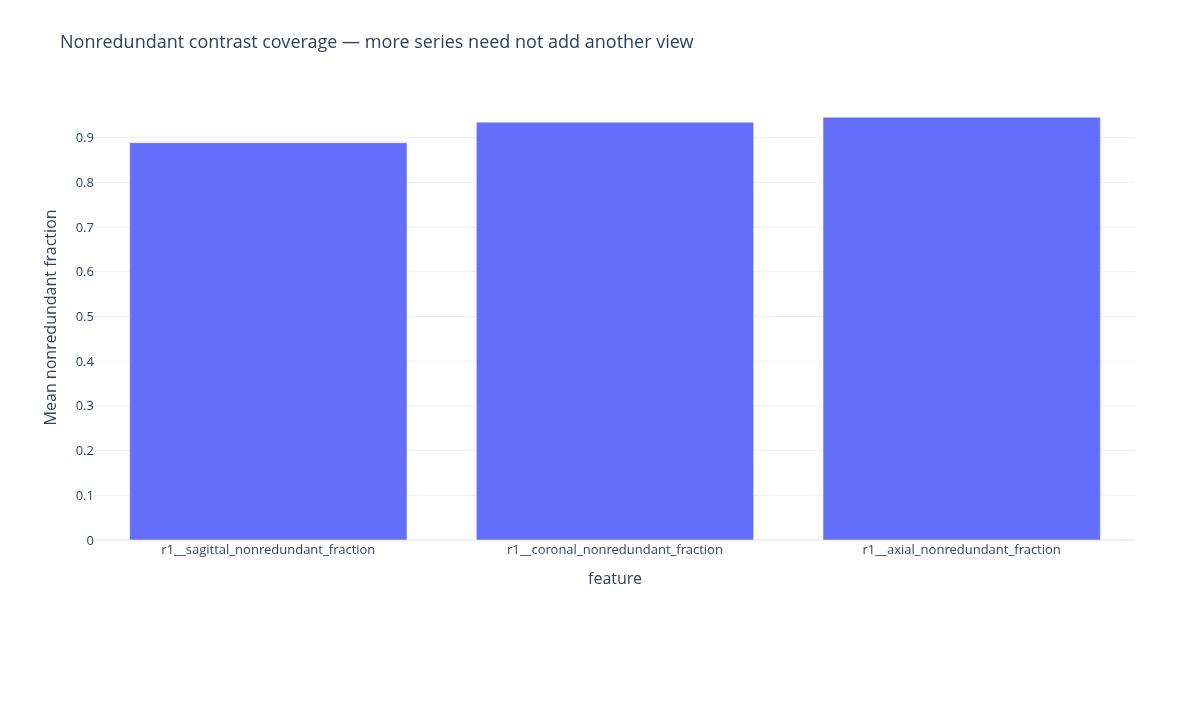

In [14]:
figure = round1_figure(DIRECTORY, 12)
figure.show(renderer='plotly_mimetype')

## Decision record and stop condition

Record all candidates as **not predictively evaluated**. No feature is promoted based on these charts. A future image-only baseline needs an approved supervision policy, patient/site leakage assessment, fixed folds, and controlled official-metric comparisons.

Save with **Ctrl+S**, close this tab, and reopen it. Verify the plots persist. Follow `NEXT_STEPS.md` for the allowlisted return ZIP; do not publish this working notebook to the public showcase.

In [15]:
print('R01_FEATURE_INVESTIGATION_COMPLETE')
print('Model fits: 0 | AUC improvement: not evaluated | Clinical validity: not established')

R01_FEATURE_INVESTIGATION_COMPLETE
Model fits: 0 | AUC improvement: not evaluated | Clinical validity: not established
